# Session 3: Reproducible practice

A labmate who graduated in June left this notebook behind. It fits a calibration for iron by the phenanthroline method and reports the iron concentration of one unknown, and the saved output says 54.5 µM. Today you find out whether that number survives a restart. Section 1 checks which Python runs the notebook, section 2 is the labmate's work with the outputs from the last time they ran it, section 3 is your record of what you fixed, and section 4 is your first judgment cell, which is practice and not scored.

**To submit.** Put your names in the next cell. Click **Restart** in the notebook toolbar, then **Run All**, check that every cell ran without an error, save, and upload `activity.ipynb` to the Session 3 assignment on Canvas by 1:30 pm on Tuesday, October 13. A pair submits one notebook with both names. It is scored 3 or 0, and it earns the 3 points if it runs from top to bottom after a restart.

*Names (both, if you work as a pair):*



## Setup and imports

All libraries for the notebook, imported once at the top.

In [1]:
import sys

import numpy as np
from scipy.stats import linregress

## Parameters

The unknown sample, measured in the same cuvette at the same wavelength as the standards.

In [3]:
UNKNOWN_TRANSMITTANCE = 30.5  # %T; unknown iron sample, 1 cm cuvette, 510 nm

## 1. Your copy of the course

This section is ours, not the labmate's. A notebook runs in a kernel, i.e., one Python program with its own set of installed packages, and VS Code shows which one in the top right corner of the notebook. The course kernel is the `.venv` folder that `uv sync` built from `pyproject.toml` and `uv.lock`, or the conda environment named `signals`. The next cell prints the Python version, where that Python lives on your laptop, and whether it is the course environment. On a course laptop the last line reads `Course environment: yes`.

In [ ]:
print("Python", sys.version.split()[0])
print(sys.executable)

in_course_env = ".venv" in sys.executable or "signals" in sys.executable
print("Course environment:", "yes" if in_course_env else "NO, change the kernel")

**Explain.** A classmate's notebook stops in its first cell with `ModuleNotFoundError: No module named 'scipy'`, and the cell above prints a location ending in `Python312\python.exe`. In the next cell, say in one or two sentences what is wrong and what they should click, and why `pip install scipy` is the wrong fix in this course.

*Your explanation:*



**Explain.** Open a terminal in your `signals-to-insights` folder and run `git status`. In the next cell, write which files it lists as modified, and say why none of them stopped `git pull` from bringing in this session.

*Your explanation:*



## 2. The labmate's notebook

The three subsections below are the labmate's, exactly as they left them, including their outputs. The notebook has five problems. Three stop **Run All** with an error. One lets the notebook run to the end and gives a wrong concentration. One gives no error and no wrong number today, and matters only when someone reruns the notebook next year. Fix each one in the labmate's cells, and record it in the rescue log in section 3 as you go.

1. Before you run anything, look at the numbers in square brackets to the left of the labmate's code cells, including the two in Setup and Parameters. Each records when that cell last ran. Answer the **Explain** cell below.
2. Click **Restart**, then **Run All**. The notebook stops at the first problem. Read the last line of the error message and the arrow above it.
3. If the message makes no sense to you, paste the whole error message into Claude Code below this prompt:

   ```text
   Explain this error message from sessions/S03-reproducible-practice/activity.ipynb. Say which line it points to and why it fails. Do not fix it.
   ```

4. Fix the cell yourself, then **Restart** and **Run All** again. To move a cell, select it and press Alt and the up arrow (Option and the up arrow on a Mac). Repeat until the notebook runs to the end.
5. When it runs to the end, ask Claude Code to review the chemistry:

   ```text
   The notebook sessions/S03-reproducible-practice/activity.ipynb now runs to the end. Read section 2 and tell me whether the calibration is done correctly for this data file, and what you would check. Do not change the notebook.
   ```

   Check what it says against your data before you change anything. That check is your judgment entry in section 4.
6. For the fifth problem, compare the end of this notebook with the end of the session 2 notebook.

**Explain.** In what order did the labmate last run their six code cells, and what does the missing number 2 suggest happened to a cell? Answer in one or two sentences.

*Your explanation:*



### Load the standards

Six iron(II) phenanthroline standards from 0 to 80 µM, exported from the spectrophotometer at 510 nm.

In [4]:
calibration   = np.loadtxt("/Users/labmate/Desktop/chem427/fe_phen_510nm.csv", delimiter=",", skiprows=1)
concentration = calibration[:, 0]  # µM
transmittance = calibration[:, 1]  # %T

print(concentration)
print(transmittance)

[ 0. 10. 20. 40. 60. 80.]
[98.9 77.7 59.3 35.6 21.6 12.9]


### Calibration

Beer-Lambert: a straight line through the standards gives the calibration, and its slope is the sensitivity.

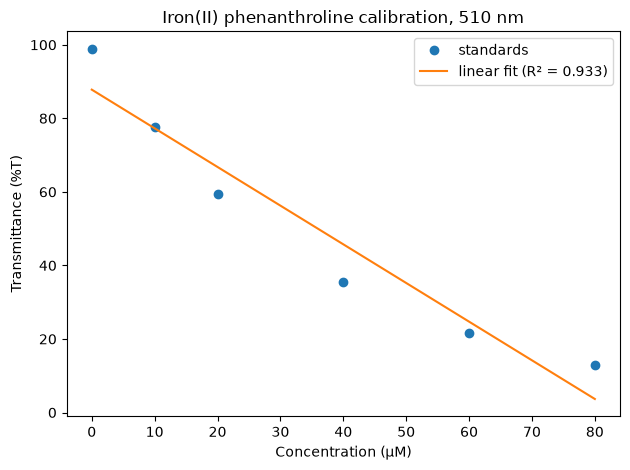

In [6]:
x_fit = np.linspace(concentration.min(), concentration.max(), 200)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots()
ax.plot(concentration, transmittance, "o", label="standards")
ax.plot(x_fit, y_fit, "-", label=f"linear fit (R² = {r_squared:.3f})")
ax.set_xlabel("Concentration (µM)")
ax.set_ylabel("Transmittance (%T)")
ax.set_title("Iron(II) phenanthroline calibration, 510 nm")
ax.legend()
fig.tight_layout()
plt.show()

The labmate's saved plot shows the six circles falling from 98.9 %T at 0 µM to 12.9 %T at 80 µM along a curve that flattens at high concentration, with the straight line below the circles at 0 and 80 µM and above them at 20 and 40 µM.

In [5]:
result    = linregress(concentration, transmittance)
slope     = result.slope
intercept = result.intercept
r_squared = result.rvalue**2

print(f"slope     {slope:.4f}")
print(f"intercept {intercept:.3f}")
print(f"R²        {r_squared:.4f}")

slope     -1.0516
intercept 87.805
R²        0.9331


### The unknown

The unknown's concentration, read from the calibration line.

In [7]:
unknown_concentration = (UNKNOWN_TRANSMITTANCE - intercept) / slope  # µM
print(f"unknown: {unknown_concentration:.1f} µM")

unknown: 54.5 µM


## 3. Rescue log

In the next cell, write one line for each of the five problems: which cell, what was wrong, and what it would have done to the next person who ran the notebook. This cell is not graded, and it is the list you will want in session 4.

*Rescue log:*

1.
2.
3.
4.
5. 

## 4. Judgment cell (practice)

From session 4 on, every notebook ends with a judgment cell scored 0 to 2, and this one is practice: it is not scored, and a member of the instructional team may leave a comment on it. Write it yourself, as you will from session 4; the format and a worked example are on the AI practices page, `ai-practices.md`. Part (a) asks what concentration you report for the unknown and how it compares with the labmate's 54.5 µM; cite your slope and one feature of your plot or residuals. Part (b) is one judgment entry about a suggestion Claude Code made during the rescue, most likely its answer to the review prompt in step 5, that you changed, rejected or verified, with a reason from your data.

**Judgment cell**

**(a)**

**(b) Judgment entry**

- **What the assistant suggested:**
- **What I did:**
- **Why, from my data:** 